## Performing Cleaning,EDA and Feature Extraction on Google Playstore Dataset

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# This is warning module of python.we ignore it if we want no warning in our output cell.
# import warnings
# warnings.filterwarnings("ignore")


%matplotlib inline


In [ ]:
df=pd.read_csv(r'"C:\Users\Devendra\Downloads\googleplaystore.csv"')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [141]:
df_copy=df.copy()

In [142]:
df_copy.fillna({'Rating':df_copy['Rating'].median()},inplace=True)
df_copy['Rating'].isnull().sum()

np.int64(0)

In [143]:
df_copy[~ df_copy['Reviews'].str.isnumeric()]
# Since it is just one column we drop it
df_copy.drop(df_copy.index[10472],inplace=True)# we drop that one row based on index

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [145]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [146]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [147]:
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size']=df_copy['Size'].astype(float)

In [148]:
cols=['Installs','Price']
for j in cols:
    for i in ['$','+',',']:
        df_copy[j]=df_copy[j].str.replace(i,'')
df_copy['Price']=df_copy['Price'].astype(float)
df_copy['Installs']=df_copy['Installs'].astype(int)
# df_copy['Price'].unique()
    
# df_copy[df_copy['Price'].str.isnumeric()]


In [149]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  object 
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 1.2+ MB


In [150]:
df_copy['Type'].unique()
df_copy['Type'].fillna('Free',inplace=True)
df_copy['Type'].isnull().sum()

C:\Users\Devendra\AppData\Local\Temp\ipykernel_21540\3544629643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Type'].fillna('Free',inplace=True)


np.int64(0)

In [151]:
df_copy['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [152]:
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'],errors='coerce')
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          10840 non-null  float64       
 3   Reviews         10840 non-null  object        
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10840 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

In [153]:
df_copy['Reviews']=df_copy['Reviews'].astype(float)

In [154]:
df_copy.to_csv(r"Data/google_cleaned_dataset")

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          10840 non-null  float64       
 3   Reviews         10840 non-null  float64       
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10840 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

# EDA

## Check for Duplicates.
### Duplicated apps are important to be held with.
### Other ctegorical features can consist duplicates as they can be similar for different apps

In [155]:
df_copy[df_copy.duplicated(subset='App')]
df_copy.drop_duplicates('App',keep='first',inplace=True)
df_copy.duplicated('App').sum()

np.int64(0)

# Exploring Data and understanding patterns through plots

In [156]:
# Understanding number of categorical features and numerical features

numerical_features=[ i for i in df_copy.columns if df_copy[i].dtype!='O']
categorical_features=[ i for i in df_copy.columns if df_copy[i].dtype=='O']

print(numerical_features)
print(categorical_features)

['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']
['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


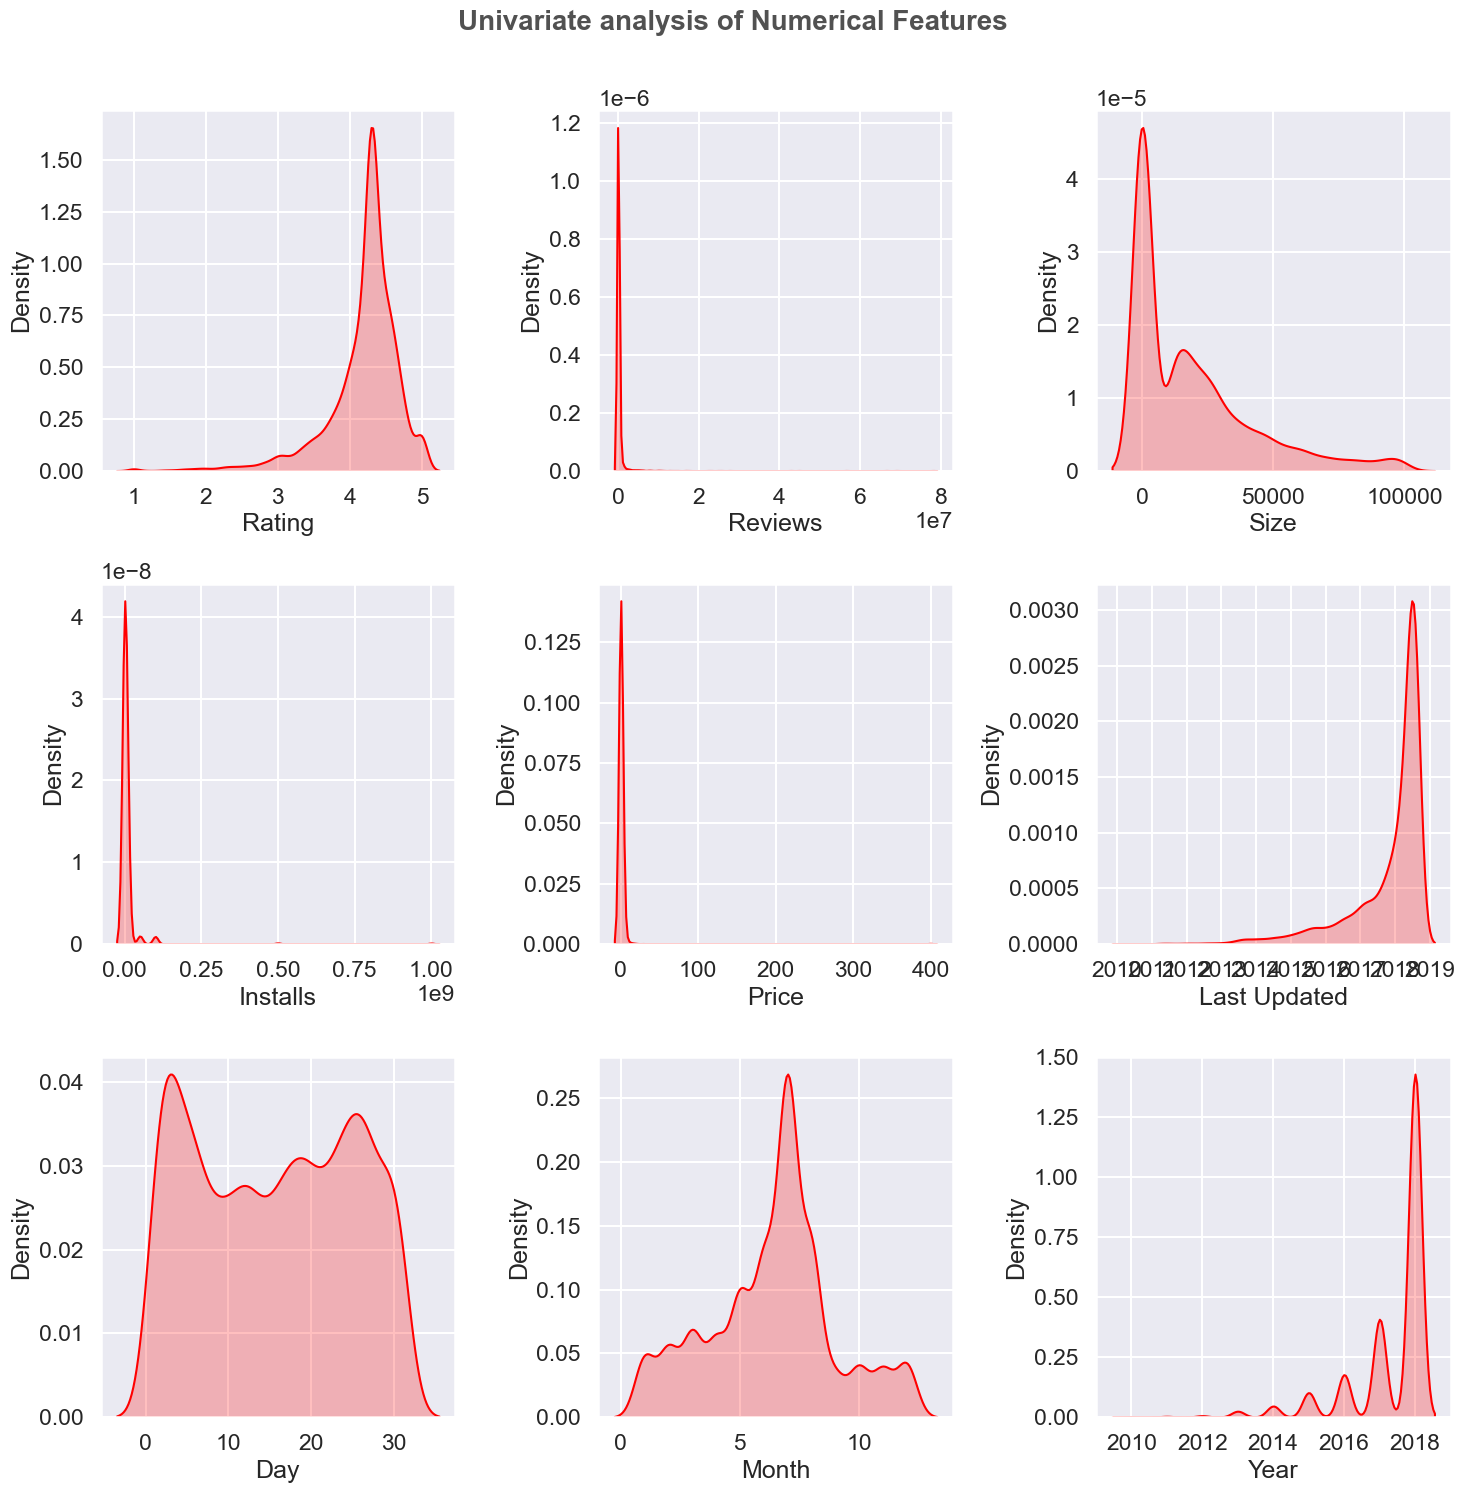

In [157]:
# Proportion of data for each numerical feature
plt.figure(figsize=(15,15),)
plt.suptitle("Univariate analysis of Numerical Features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)

for i in range(0,len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x=df_copy[numerical_features[i]],fill=True,color='r')
    plt.xlabel(numerical_features[i])
    
plt.tight_layout()


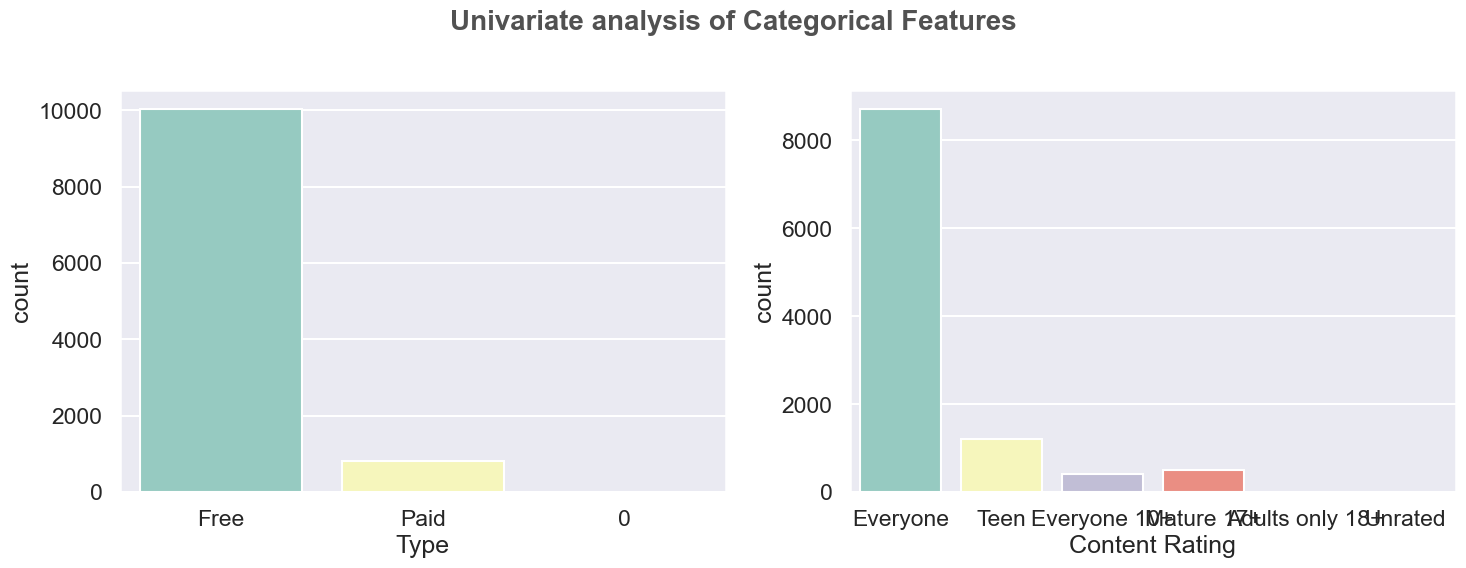

In [158]:
#Proportion of data for each categorical feature
plt.figure(figsize=(15,15),)
plt.suptitle("Univariate analysis of Categorical Features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)
category=['Type','Content Rating']
for i in range(0,len(category)):
    plt.subplot(3,2,i+1)
    sns.countplot(x=df[category[i]],hue=df[category[i]],palette='Set3',legend=False)
    plt.xlabel(category[i])
plt.tight_layout()

## Which is the most popular app category?

<Axes: ylabel='count'>

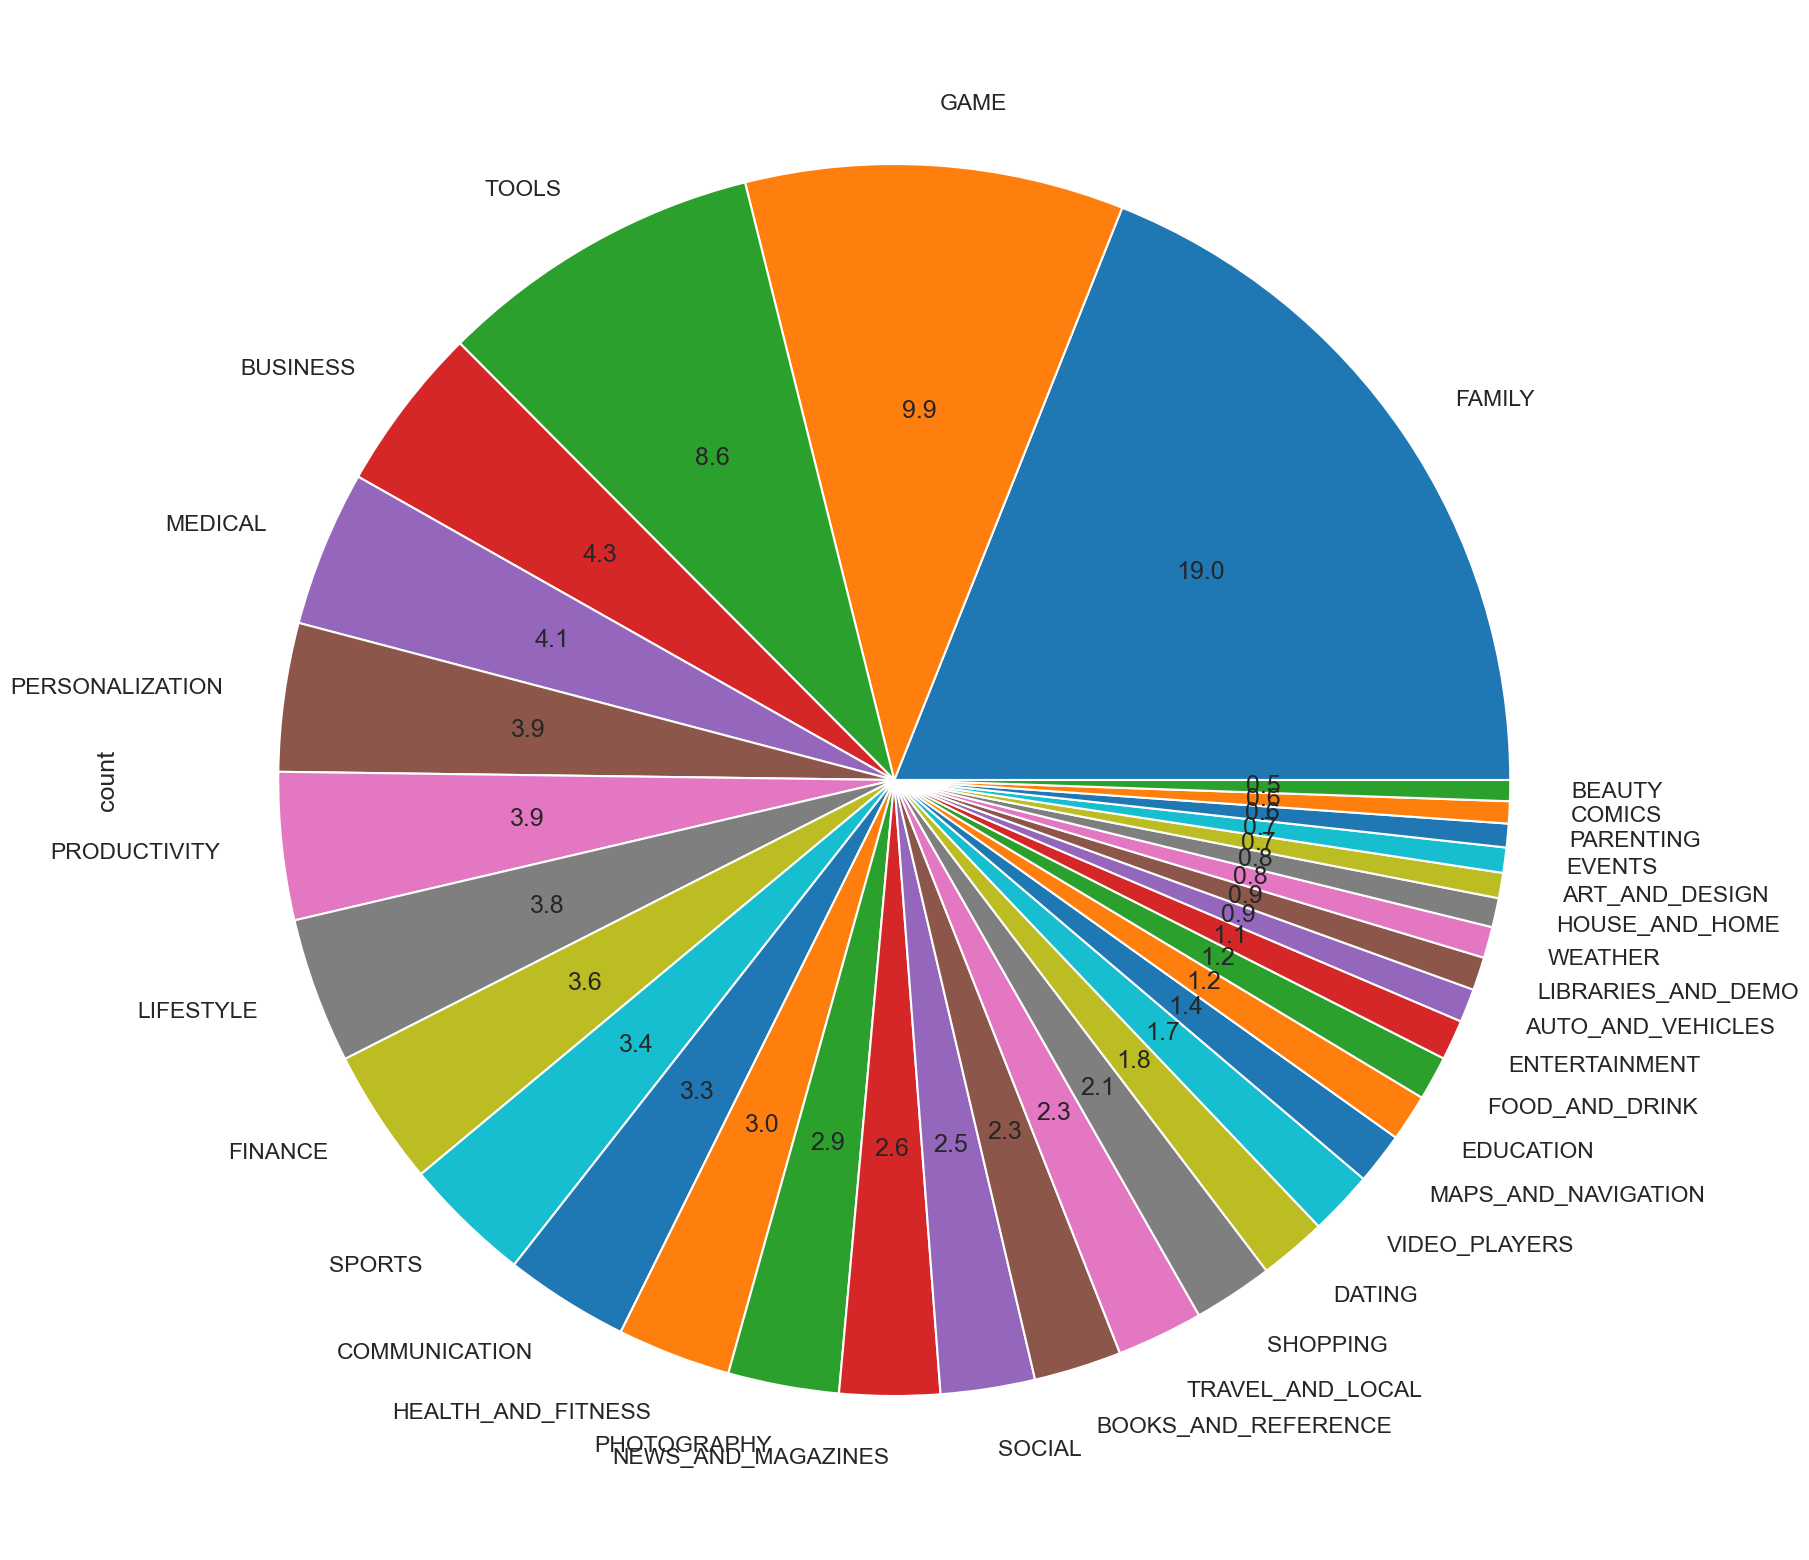

In [159]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],autopct='%1.1f',figsize=(20,20))

### From above chart we can observe that majority of the apps in Play Store belong to Family,Game and Tools

## What are the top 10 app categories ?

In [160]:
df_app_categories=pd.DataFrame(df_copy['Category'].value_counts())
df_app_categories.reset_index(inplace=True)
df_app_categories

,Category,count
0,FAMILY,1832
1,GAME,959
2,TOOLS,827
3,BUSINESS,420
4,MEDICAL,395
5,PERSONALIZATION,376
6,PRODUCTIVITY,374
7,LIFESTYLE,369
8,FINANCE,345
9,SPORTS,325


C:\Users\Devendra\AppData\Local\Temp\ipykernel_21540\1492805391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Figure size 1000x1000 with 0 Axes>

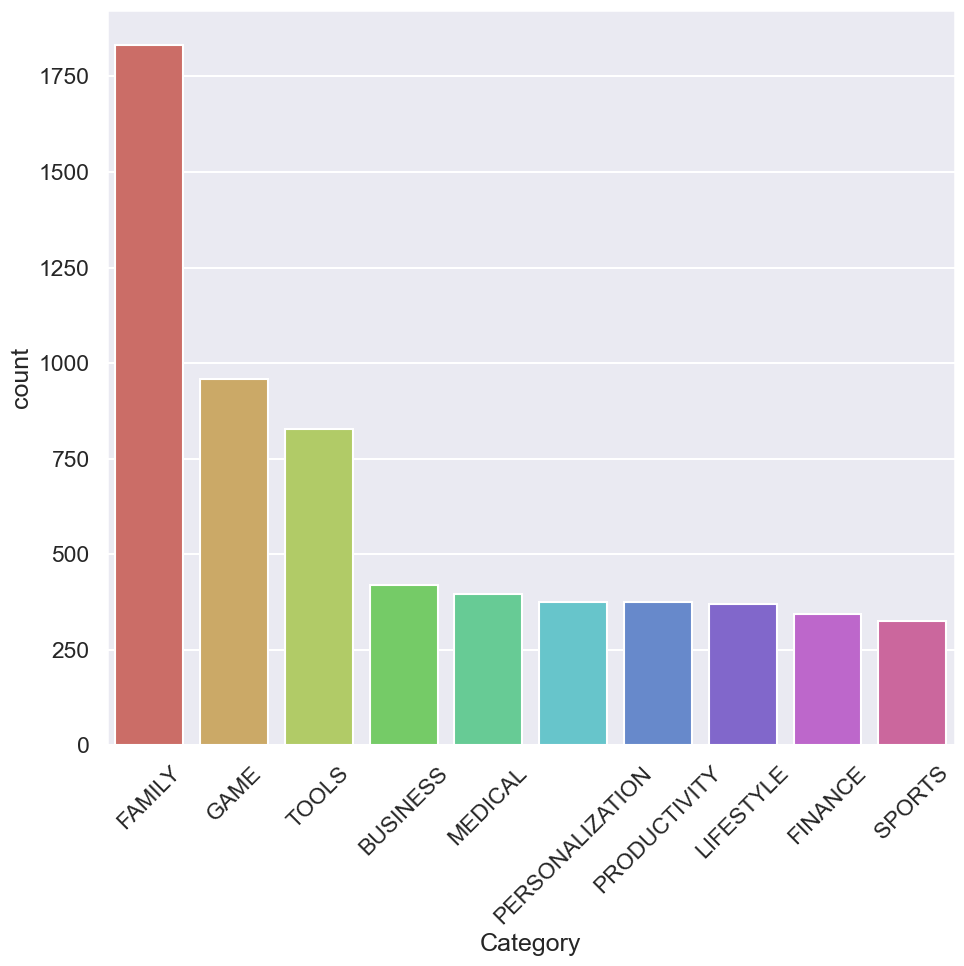

In [161]:
plt.figure(figsize=(10,10))
plt.figure(figsize=(10,10))

sns.barplot(
    x='Category',
    y='count',
    data=df_app_categories[:10],
    palette='hls'
)

plt.xlabel("Category")
plt.xticks(rotation=45)  # helps if names are long
plt.tight_layout()
plt.show()

## Insights
1. Family category has the most number of apps with 18% of apps belonging to it, followed by Games category which has 11% of the apps.
2. Least number of apps belong to the Beauty category with less than 1% of the total apps belonging to it.


## Internal Assignments
1. Which Category has largest number of installations??


In [162]:
df_category_by_install = df_copy.groupby('Category')['Installs'].sum().reset_index().sort_values(by='Installs',ascending=False)
df_category_by_install.Installs=df_category_by_install.Installs/1000000000
df_category_by_install.rename(columns={"Installs":"Install(in B's)"},inplace=True)
df_category_by_install.reset_index(drop=True)

,Category,Install(in B's)
0,GAME,13.878924
1,COMMUNICATION,11.038276
2,TOOLS,8.001772
3,PRODUCTIVITY,5.793091
4,SOCIAL,5.487868
5,PHOTOGRAPHY,4.649148
6,FAMILY,4.427942
7,VIDEO_PLAYERS,3.926903
8,TRAVEL_AND_LOCAL,2.894887
9,NEWS_AND_MAGAZINES,2.369218


C:\Users\Devendra\AppData\Local\Temp\ipykernel_21540\3221311703.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Install(in B's)",y='Category',data=df_category_by_install[:10],palette='hls')


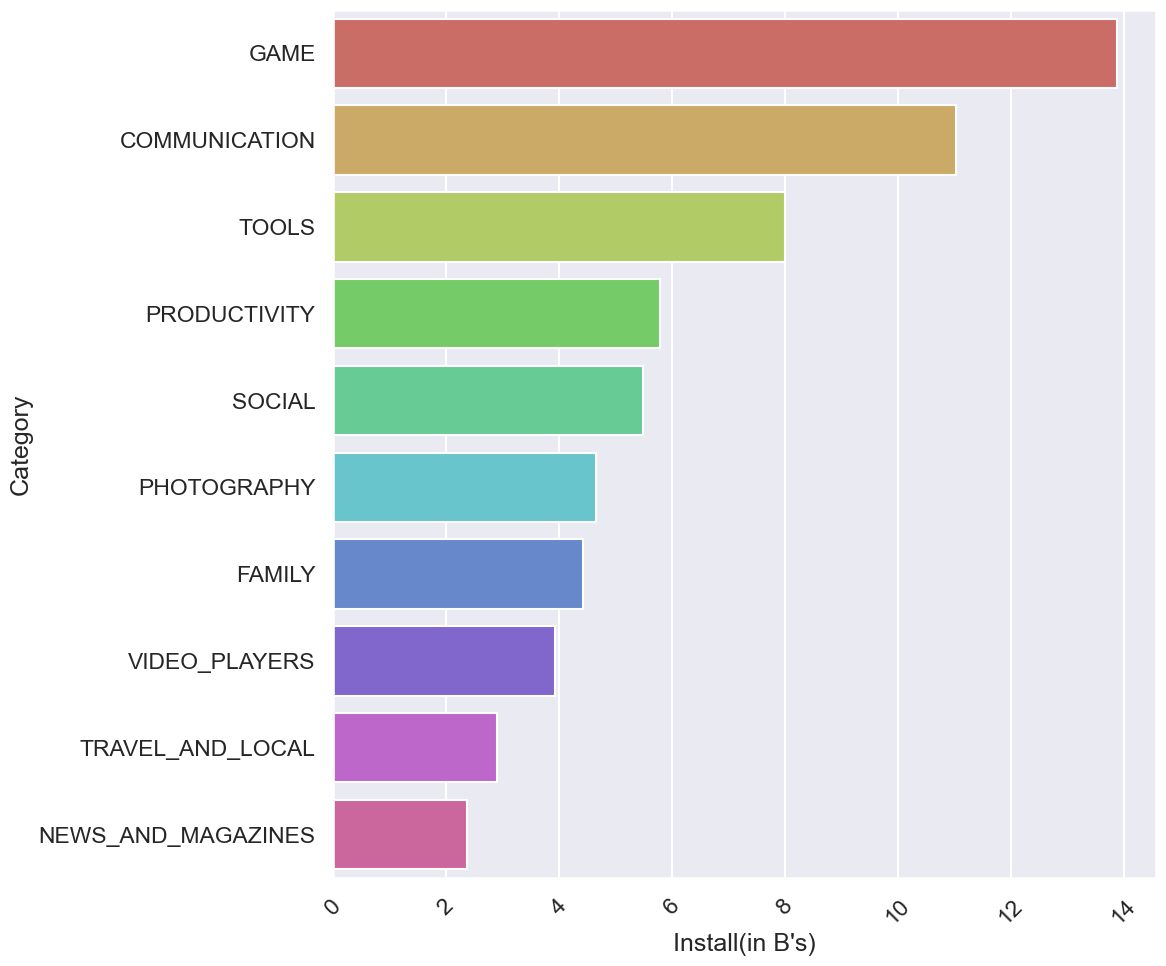

In [163]:
#Plotting for visualising the most downlaoded category

plt.figure(figsize=(12,10))

sns.set_context("talk")
sns.set_style("darkgrid")
sns.barplot(x="Install(in B's)",y='Category',data=df_category_by_install[:10],palette='hls')



plt.xticks(rotation=45)  # helps if names are long
plt.tight_layout()
plt.show()

## Insights
1. Out of all the categories "GAME" has the most number of Installations.
2. With almost 35 Billion Installations GAME is the most popular Category in Google App store    

## 2. What are the Top 5 most installed Apps in Each popular Categories ??

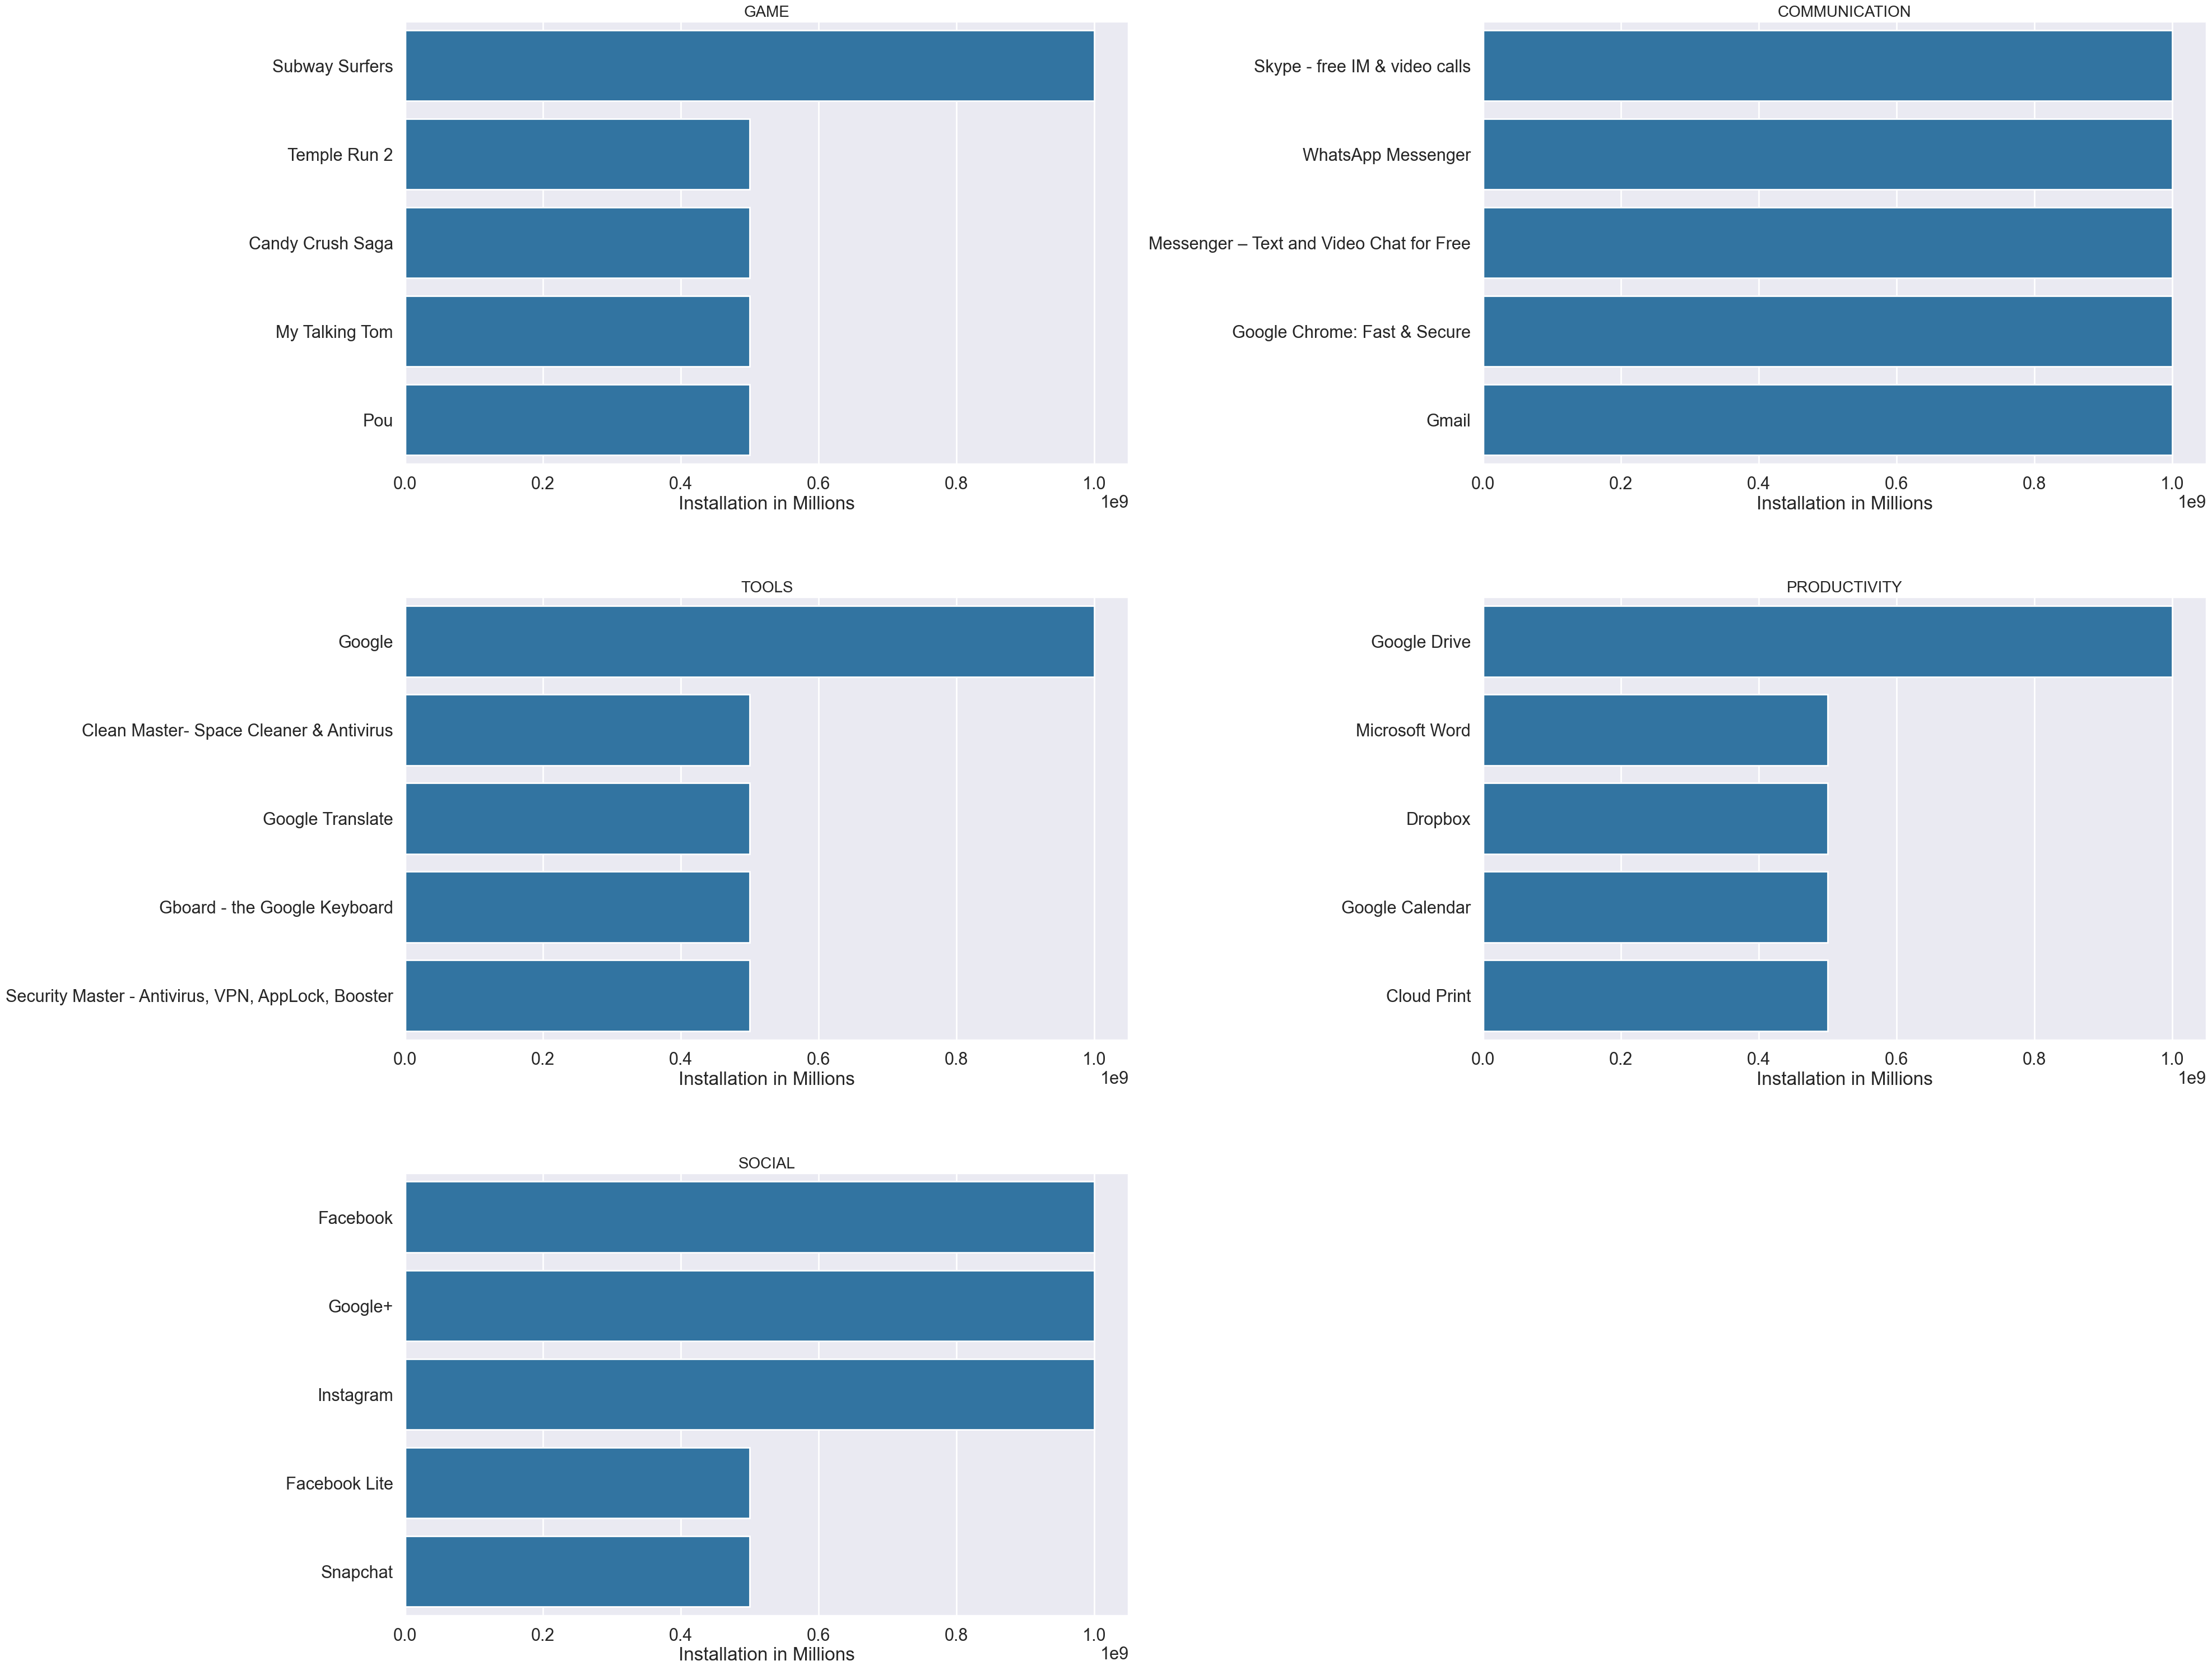

In [183]:
df_popular_install=df_copy.groupby(['Category','App'])['Installs'].sum().reset_index()
df_popular_install.sort_values(by='Installs',ascending=False,inplace=True)

sns.set_context("poster")
sns.set_style("darkgrid")

plt.figure(figsize=(40,50))
categories=df_copy.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(5).index.to_list()

for i,category1 in enumerate(categories):
    new_df1=df_popular_install[df_popular_install.Category==category1]
    new_df2=new_df1.head(5)
    plt.subplot(5,2,i+1)
    sns.barplot(x='Installs',y='App',data=new_df2)
    plt.xlabel('Installation in Millions')
    plt.ylabel('')
    plt.title(category1,size = 20)
    
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()


In [179]:
df_popular_install

,Category,App,Installs
9342,TRAVEL_AND_LOCAL,Maps - Navigate & Explore,1000000000
1534,ENTERTAINMENT,Google Play Games,1000000000
9496,VIDEO_PLAYERS,Google Play Movies & TV,1000000000
6388,NEWS_AND_MAGAZINES,Google News,1000000000
1145,COMMUNICATION,Skype - free IM & video calls,1000000000
...,...,...,...
547,BUSINESS,CX Network,0
3661,FINANCE,Eu Sou Rico,0
2211,FAMILY,Command & Conquer: Rivals,0
3662,FINANCE,Eu sou Rico,0


## Insights
- Most popular game is Subway Surfers.
- Most popular communication app is Hangouts.
- Most popular productivity app is Google Drive.
- Most popular social app is Instagram.

# 3. How many apps are there on Google Play Store which get 5 ratings??

In [198]:


df_rating=df_copy.groupby(['App','Category'])['Rating'].sum().sort_values(ascending=False).reset_index()
top_rating_apps=df_rating[df_rating.Rating==5]
top_rating_apps.head(1)


,App,Category,Rating
0,Color CL,LIFESTYLE,5.0


## Result
- There are 271 five rated apps on Google Play store
- Top most is 'Color CL' from 'Lifestyle' Category